#  Superstore Sales Analysis

## Import Libraries

In [52]:
import pandas as pd 
import matplotlib.pyplot as plt

## Import Data

In [53]:
df =  pd.read_csv(r"C:\Users\lenovo\Desktop\SuperStoreOrders.csv")

In [54]:
df.head()

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,1/1/2011,6/1/2011,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Office Supplies,Storage,"Tenex Lockers, Blue",408,2,0.0,106.140,35.46,Medium,2011
1,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Office Supplies,Supplies,"Acme Trimmer, High Speed",120,3,0.1,36.036,9.72,Medium,2011
2,HU-2011-1220,1/1/2011,5/1/2011,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,Office Supplies,Storage,"Tenex Box, Single Width",66,4,0.0,29.640,8.17,High,2011
3,IT-2011-3647632,1/1/2011,5/1/2011,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,Office Supplies,Paper,"Enermax Note Cards, Premium",45,3,0.5,-26.055,4.82,High,2011
4,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114,5,0.1,37.770,4.70,Medium,2011


In [55]:
df.shape

(51290, 21)

In [56]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        51290 non-null  str    
 1   order_date      51290 non-null  str    
 2   ship_date       51290 non-null  str    
 3   ship_mode       51290 non-null  str    
 4   customer_name   51290 non-null  str    
 5   segment         51290 non-null  str    
 6   state           51290 non-null  str    
 7   country         51290 non-null  str    
 8   market          51290 non-null  str    
 9   region          51290 non-null  str    
 10  product_id      51290 non-null  str    
 11  category        51290 non-null  str    
 12  sub_category    51290 non-null  str    
 13  product_name    51290 non-null  str    
 14  sales           51290 non-null  str    
 15  quantity        51290 non-null  int64  
 16  discount        51290 non-null  float64
 17  profit          51290 non-null  float64
 1

In [57]:
df.isnull().sum()

order_id          0
order_date        0
ship_date         0
ship_mode         0
customer_name     0
segment           0
state             0
country           0
market            0
region            0
product_id        0
category          0
sub_category      0
product_name      0
sales             0
quantity          0
discount          0
profit            0
shipping_cost     0
order_priority    0
year              0
dtype: int64

In [58]:
df.duplicated().sum()

np.int64(0)

In [59]:
df.columns

Index(['order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_name',
       'segment', 'state', 'country', 'market', 'region', 'product_id',
       'category', 'sub_category', 'product_name', 'sales', 'quantity',
       'discount', 'profit', 'shipping_cost', 'order_priority', 'year'],
      dtype='str')

In [61]:
df['order_date'].head(20)

0     1/1/2011
1     1/1/2011
2     1/1/2011
3     1/1/2011
4     1/1/2011
5     1/1/2011
6     2/1/2011
7     3/1/2011
8     3/1/2011
9     3/1/2011
10    3/1/2011
11    3/1/2011
12    3/1/2011
13    3/1/2011
14    3/1/2011
15    3/1/2011
16    3/1/2011
17    3/1/2011
18    3/1/2011
19    3/1/2011
Name: order_date, dtype: str

In [62]:
df['order_date'].sample(10)

25310    28-06-2013
47463     8/11/2014
326      24-01-2011
44741    21-09-2014
47135     4/11/2014
22714    25-04-2013
34209    17-01-2014
50356    18-12-2014
28056      5/9/2013
23546    23-05-2013
Name: order_date, dtype: str

In [63]:
df['order_date'] = pd.to_datetime(
    df['order_date'],
    format='mixed',
    dayfirst=True
)

df['ship_date'] = pd.to_datetime(
    df['ship_date'],
    format='mixed',
    dayfirst=True
)

In [64]:
import pandas as pd
print(pd.__version__)

3.0.2


In [65]:
df['order_date'] = pd.to_datetime(
    df['order_date'],
    format='mixed',
    dayfirst=True,
    errors='coerce'
)

df['ship_date'] = pd.to_datetime(
    df['ship_date'],
    format='mixed',
    dayfirst=True,
    errors='coerce'
)

In [66]:
df[['order_date', 'ship_date']].head()

,order_date,ship_date
0,2011-01-01,2011-01-06
1,2011-01-01,2011-01-08
2,2011-01-01,2011-01-05
3,2011-01-01,2011-01-05
4,2011-01-01,2011-01-08


In [67]:
df.dtypes

order_id                     str
order_date        datetime64[us]
ship_date         datetime64[us]
ship_mode                    str
customer_name                str
segment                      str
state                        str
country                      str
market                       str
region                       str
product_id                   str
category                     str
sub_category                 str
product_name                 str
sales                        str
quantity                   int64
discount                 float64
profit                   float64
shipping_cost            float64
order_priority               str
year                       int64
dtype: object

In [68]:
df['order_date'].dtype

dtype('<M8[us]')

In [69]:
df['order_date'].head(20)

0    2011-01-01
1    2011-01-01
2    2011-01-01
3    2011-01-01
4    2011-01-01
5    2011-01-01
6    2011-01-02
7    2011-01-03
8    2011-01-03
9    2011-01-03
10   2011-01-03
11   2011-01-03
12   2011-01-03
13   2011-01-03
14   2011-01-03
15   2011-01-03
16   2011-01-03
17   2011-01-03
18   2011-01-03
19   2011-01-03
Name: order_date, dtype: datetime64[us]

In [70]:
df.head(5)

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,2011-01-01,2011-01-06,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Office Supplies,Storage,"Tenex Lockers, Blue",408,2,0.0,106.140,35.46,Medium,2011
1,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Office Supplies,Supplies,"Acme Trimmer, High Speed",120,3,0.1,36.036,9.72,Medium,2011
2,HU-2011-1220,2011-01-01,2011-01-05,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,Office Supplies,Storage,"Tenex Box, Single Width",66,4,0.0,29.640,8.17,High,2011
3,IT-2011-3647632,2011-01-01,2011-01-05,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,Office Supplies,Paper,"Enermax Note Cards, Premium",45,3,0.5,-26.055,4.82,High,2011
4,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114,5,0.1,37.770,4.70,Medium,2011


In [71]:
df['ship_date'].head()

0   2011-01-06
1   2011-01-08
2   2011-01-05
3   2011-01-05
4   2011-01-08
Name: ship_date, dtype: datetime64[us]

In [72]:
df['month'] = df['order_date'].dt.to_period('M')
df.groupby('month')['sales'].sum()

month
2011-01    4081206645114553142769126673382118541931591951...
2011-02    2862912061633524013101404182782320212112101,05...
2011-03    5511,3141,4713646342467051,2442154585883771953...
2011-04    4972965681581398486123804868122452044302518671...
2011-05    2,7541,0574801,3892463095213372661562362888147...
2011-06    1,0381,0291,5038822,00280648245038951222390212...
2011-07    1,88857662313946362342920551717435462532680017...
2011-08    1,1585171,504923270217249992799940805225319653...
2011-09    1,4291,2337681,1001834742433571383481868812578...
2011-10    1,017232104105665222139531823013155971,5271,23...
2011-11    1,9847431,5931,5502835275947709794443891976779...
2011-12    2,8081,7969106741,1811,89418027266022049139211...
2012-01    2,8221,2304174131,1886279162744521782452651032...
2012-02    59415220019394579670140339193,2639651,7791,109...
2012-03    1,22873359796190555076383824540604622518342,10...
2012-04    4004269529636643608818306501097214412073884850...
2012-05    3851,34

In [73]:
df['sales'].dtype

<StringDtype(storage='python', na_value=nan)>

In [74]:
df['sales'] = pd.to_numeric(df['sales'], errors='coerce')

In [75]:
df['sales'].dtype

dtype('float64')

# Busines Analysis

## Total Sales

In [76]:
df['sales'].sum()

np.float64(7835128.0)

## Region wise Sales

In [77]:
df.groupby('region')['sales'].sum()

region
Africa             538115.0
Canada              50314.0
Caribbean          251441.0
Central           1806638.0
Central Asia       389506.0
EMEA               575562.0
East               366492.0
North              790546.0
North Asia         453686.0
Oceania            625382.0
South             1031101.0
Southeast Asia     532172.0
West               424173.0
Name: sales, dtype: float64

## Category-wise Profit

In [78]:
df.groupby('category')['profit'].sum().sort_values(ascending=False)

category
Technology         663778.73318
Office Supplies    518473.83430
Furniture          286782.25380
Name: profit, dtype: float64

## Monthly Sales Trend

In [79]:
df['month']=df['order_date'].dt.to_period('M')
df.groupby('month')['sales'].sum()

month
2011-01     64363.0
2011-02     60848.0
2011-03     78983.0
2011-04     80698.0
2011-05     91536.0
2011-06    142526.0
2011-07     75412.0
2011-08    132065.0
2011-09    153992.0
2011-10    122853.0
2011-11    175221.0
2011-12    199654.0
2012-01     81584.0
2012-02     64671.0
2012-03    100896.0
2012-04    102668.0
2012-05    133087.0
2012-06    173758.0
2012-07     98307.0
2012-08    167188.0
2012-09    180593.0
2012-10    155952.0
2012-11    225179.0
2012-12    197616.0
2013-01    100754.0
2013-02     94149.0
2013-03    125709.0
2013-04    118212.0
2013-05    152534.0
2013-06    232624.0
2013-07    155678.0
2013-08    209172.0
2013-09    253211.0
2013-10    169227.0
2013-11    239563.0
2013-12    256188.0
2014-01    139080.0
2014-02    120322.0
2014-03    160887.0
2014-04    154016.0
2014-05    185021.0
2014-06    258276.0
2014-07    158948.0
2014-08    276557.0
2014-09    305570.0
2014-10    257664.0
2014-11    348457.0
2014-12    303659.0
Freq: M, Name: sales, dtype: float

In [80]:
df.groupby('region')['sales'].sum()

region
Africa             538115.0
Canada              50314.0
Caribbean          251441.0
Central           1806638.0
Central Asia       389506.0
EMEA               575562.0
East               366492.0
North              790546.0
North Asia         453686.0
Oceania            625382.0
South             1031101.0
Southeast Asia     532172.0
West               424173.0
Name: sales, dtype: float64

## Top 10 Customers

In [81]:
df.groupby('customer_name')['sales'].sum().sort_values(ascending=False).head(10)

customer_name
Eric Murdock        19489.0
John Grady          19483.0
Maria Etezadi       18237.0
Theone Pippenger    17416.0
Dan Reichenbach     16705.0
Ben Ferrer          16661.0
Randy Bradley       16399.0
Mathew Reese        16125.0
Muhammed Yedwab     16091.0
Steven Ward         15984.0
Name: sales, dtype: float64

In [82]:
df.groupby('category')['profit'].sum()

category
Furniture          286782.25380
Office Supplies    518473.83430
Technology         663778.73318
Name: profit, dtype: float64

In [83]:
df.groupby('customer_name')['sales'].sum().sort_values(ascending=False).head(10)

customer_name
Eric Murdock        19489.0
John Grady          19483.0
Maria Etezadi       18237.0
Theone Pippenger    17416.0
Dan Reichenbach     16705.0
Ben Ferrer          16661.0
Randy Bradley       16399.0
Mathew Reese        16125.0
Muhammed Yedwab     16091.0
Steven Ward         15984.0
Name: sales, dtype: float64

In [ ]:
## Visuliazation

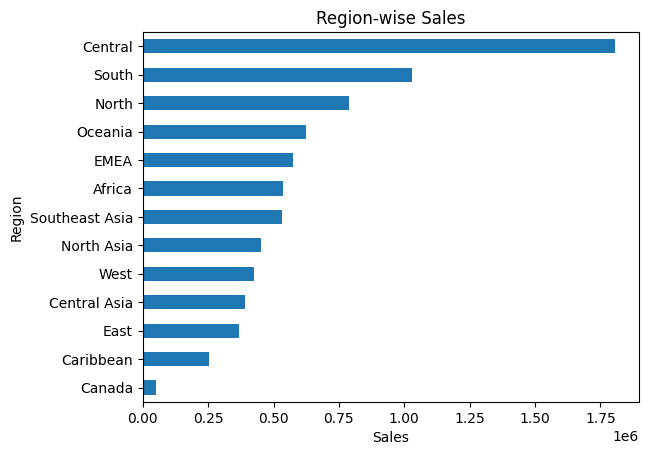

In [84]:
df.groupby('region')['sales'].sum().sort_values().plot(kind='barh')

plt.title("Region-wise Sales")
plt.xlabel("Sales")
plt.ylabel("Region")
plt.show()

## Category profit graph

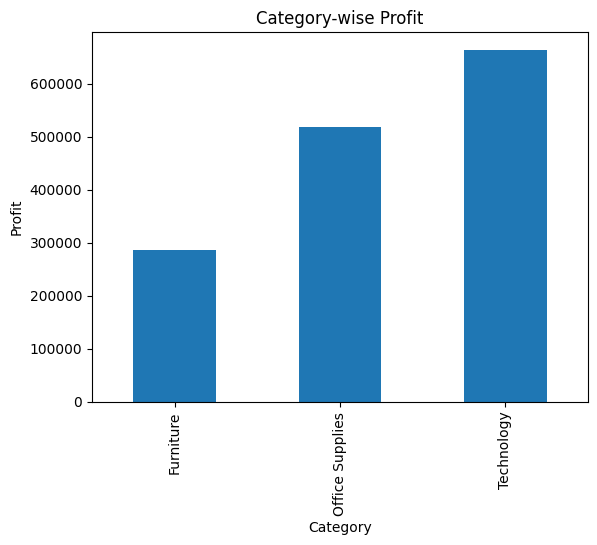

In [85]:
df.groupby('category')['profit'].sum().plot(kind='bar')

plt.title("Category-wise Profit")
plt.xlabel("Category")
plt.ylabel("Profit")
plt.show()

## Top customers

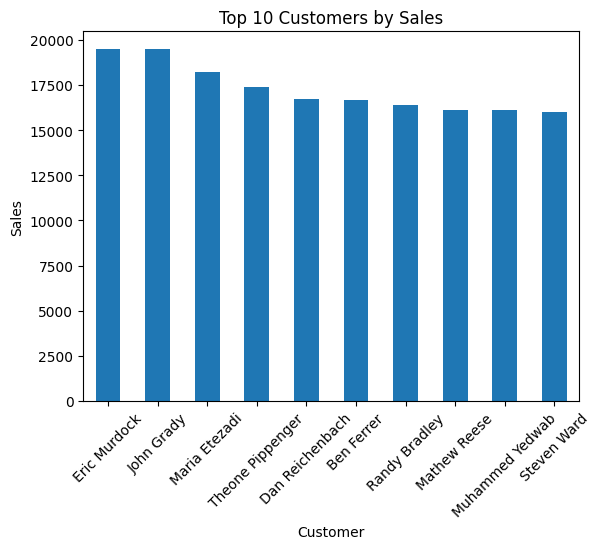

In [87]:
df.groupby('customer_name')['sales'].sum().sort_values(ascending=False).head(10).plot(kind='bar')

plt.title("Top 10 Customers by Sales")
plt.xlabel("Customer")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

## Time Series

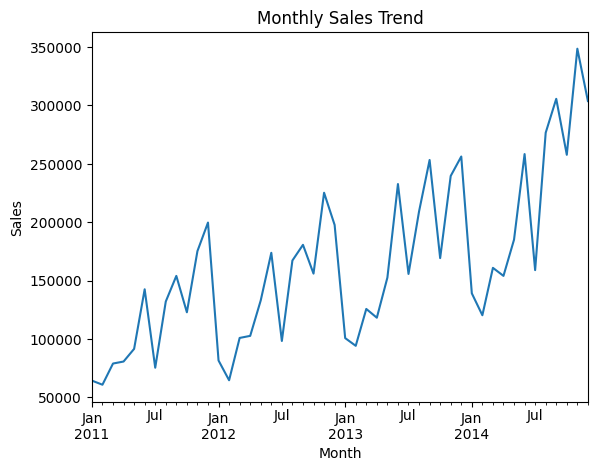

In [88]:
df['month'] = df['order_date'].dt.to_period('M')
df.groupby('month')['sales'].sum().plot()

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()